# Best Model Evaluation Notebook



# Pneumothorax

**Lightweight evaluation notebook for pneumothorax segmentation model**

- Loads best model: `pneumo_dice0.8411_iou0.8203_ep16.pth`
- Samples 5 images from each class (with/without pneumothorax)
- Performs EDA visualization
- Evaluates with TTA (Test-Time Augmentation)
- Visualizes predictions

In [1]:
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from concurrent.futures import ThreadPoolExecutor
import torchvision.io


import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.9.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# Configuration
class Config:
    DATA_PATH = "siim-acr-pneumothorax"
    TRAIN_CSV = "stage_1_train_images.csv"
    TEST_CSV = "stage_1_test_images.csv"  # Use test dataset for evaluation
    IMAGES_DIR = "png_images"
    MASKS_DIR = "png_masks"
    MODEL_PATH = "sota_output/pneumo_dice0.8411_iou0.8203_ep16.pth"
    
    ENCODER = "efficientnet-b1"
    ENCODER_WEIGHTS = "imagenet"
    ATTENTION_TYPE = "scse"
    PATCH_SIZE = 512
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 2
    NUM_WORKERS = 2
    
    SEED = 40

config = Config()

# Set seed
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
torch.cuda.manual_seed_all(config.SEED)
torch.backends.cudnn.deterministic = True

print(f"Device: {config.DEVICE}")
print(f"Model: {config.MODEL_PATH}")


Device: cuda
Model: sota_output/pneumo_dice0.8411_iou0.8203_ep16.pth


In [3]:
# Dataset class (same as training)
class PneumothoraxDataset(Dataset):
    def __init__(self, df, images_dir, masks_dir, transform=None, patch_size=768):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.patch_size = patch_size
    
    def __len__(self):
        return len(self.df)
    
    def _max_pool_downsample_mask(self, mask, target_size):
        h, w = mask.shape
        if h == target_size and w == target_size:
            return mask
        ratio = h // target_size
        if ratio > 1 and h % target_size == 0 and w % target_size == 0:
            mask_reshaped = mask.reshape(target_size, ratio, target_size, ratio)
            mask_downsampled = mask_reshaped.max(axis=(1, 3))
            return mask_downsampled
        else:
            return cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    
    def __getitem__(self, idx):
        filename = self.df.iloc[idx]['new_filename']
        image = cv2.imread(os.path.join(self.images_dir, filename), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(self.masks_dir, filename), cv2.IMREAD_GRAYSCALE)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        image = cv2.resize(image, (self.patch_size, self.patch_size))
        mask = self._max_pool_downsample_mask(mask, self.patch_size)
        
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)
        
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image, mask = transformed['image'], transformed['mask']
        
        mask = mask.permute(2, 0, 1) if mask.dim() == 3 else mask.unsqueeze(0)
        return image, mask

# Augmentation (validation - no random transforms)
def get_validation_augmentation():
    return A.Compose([
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2()
    ])

print("Dataset class and augmentation defined")


Dataset class and augmentation defined


In [4]:
# Load TEST dataset (not train - for proper evaluation)
test_csv_path = os.path.join(config.DATA_PATH, config.TEST_CSV)
df_test = pd.read_csv(test_csv_path)

images_dir = os.path.join(config.DATA_PATH, config.IMAGES_DIR)
masks_dir = os.path.join(config.DATA_PATH, config.MASKS_DIR)

# GPU-accelerated label determination
def validate_sample(df, idx):
    """Validate a sample and determine pneumothorax label using GPU-accelerated reading."""
    filename = df.iloc[idx]['new_filename']
    mask_path = os.path.join(masks_dir, filename)
    
    try:
        # Use torchvision.io for GPU-accelerated reading
        device = "cuda" if torch.cuda.is_available() else "cpu"
        mask = torchvision.io.read_image(mask_path).to(device)
        
        # Convert to grayscale if needed (handle C,H,W format)
        if mask.shape[0] > 1:
            mask = mask.mean(dim=0, keepdim=True)
        
        mask_max = mask.max().item() if mask is not None else 0
        pneumo_label = 1 if mask_max > 0 else 0
        
        return idx, pneumo_label, None
    except Exception as e:
        return None, None, filename

# GPU-accelerated validation with parallel processing
print("Determining pneumothorax labels from TEST dataset (GPU-accelerated)...")
test_valid_indices = []
test_has_pneumothorax = []

with ThreadPoolExecutor(max_workers=16) as executor:
    futures = [executor.submit(validate_sample, df_test, idx) for idx in range(len(df_test))]
    for f in tqdm(futures, desc="Checking masks"):
        try:
            idx, pneumo, corrupt = f.result()
            if idx is not None:
                test_valid_indices.append(idx)
                test_has_pneumothorax.append(pneumo)
        except Exception:
            continue

# Create filtered dataframe and labels array
df_test = df_test.iloc[test_valid_indices].reset_index(drop=True)
has_pneumothorax = np.array(test_has_pneumothorax)

print(f"\nTotal TEST samples: {len(df_test)}")
print(f"With pneumothorax: {has_pneumothorax.sum()} ({100*has_pneumothorax.mean():.1f}%)")
print(f"Without pneumothorax: {len(has_pneumothorax) - has_pneumothorax.sum()} ({100*(1-has_pneumothorax.mean()):.1f}%)")


Determining pneumothorax labels from TEST dataset (GPU-accelerated)...


Checking masks:   0%|          | 0/1372 [00:00<?, ?it/s]


Total TEST samples: 1372
With pneumothorax: 290 (21.1%)
Without pneumothorax: 1082 (78.9%)


In [5]:
# Sample 5 images from each class
positive_indices = np.where(has_pneumothorax == 1)[0]
negative_indices = np.where(has_pneumothorax == 0)[0]

np.random.seed(config.SEED)
n_samples = 5

pos_samples = np.random.choice(positive_indices, min(n_samples, len(positive_indices)), replace=False)
neg_samples = np.random.choice(negative_indices, min(n_samples, len(negative_indices)), replace=False)

sample_indices = np.concatenate([pos_samples, neg_samples])
sample_labels = ['With Pneumothorax'] * len(pos_samples) + ['Without Pneumothorax'] * len(neg_samples)

# Create dataset for samples (using test dataset)
sample_df = df_test.iloc[sample_indices].reset_index(drop=True)
sample_dataset = PneumothoraxDataset(
    sample_df, images_dir, masks_dir,
    get_validation_augmentation(),
    config.PATCH_SIZE
)

print(f"Selected {len(pos_samples)} samples with pneumothorax")
print(f"Selected {len(neg_samples)} samples without pneumothorax")


Selected 5 samples with pneumothorax
Selected 5 samples without pneumothorax


## EDA: Visualize Sample Images


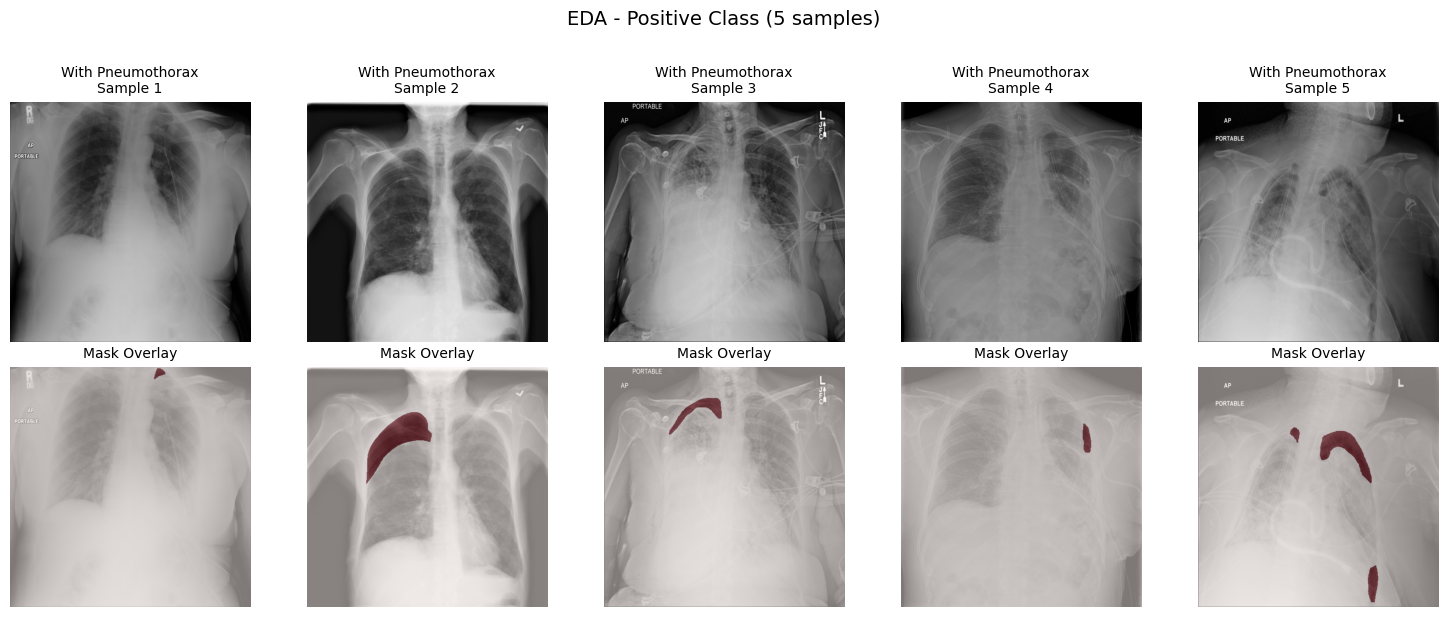

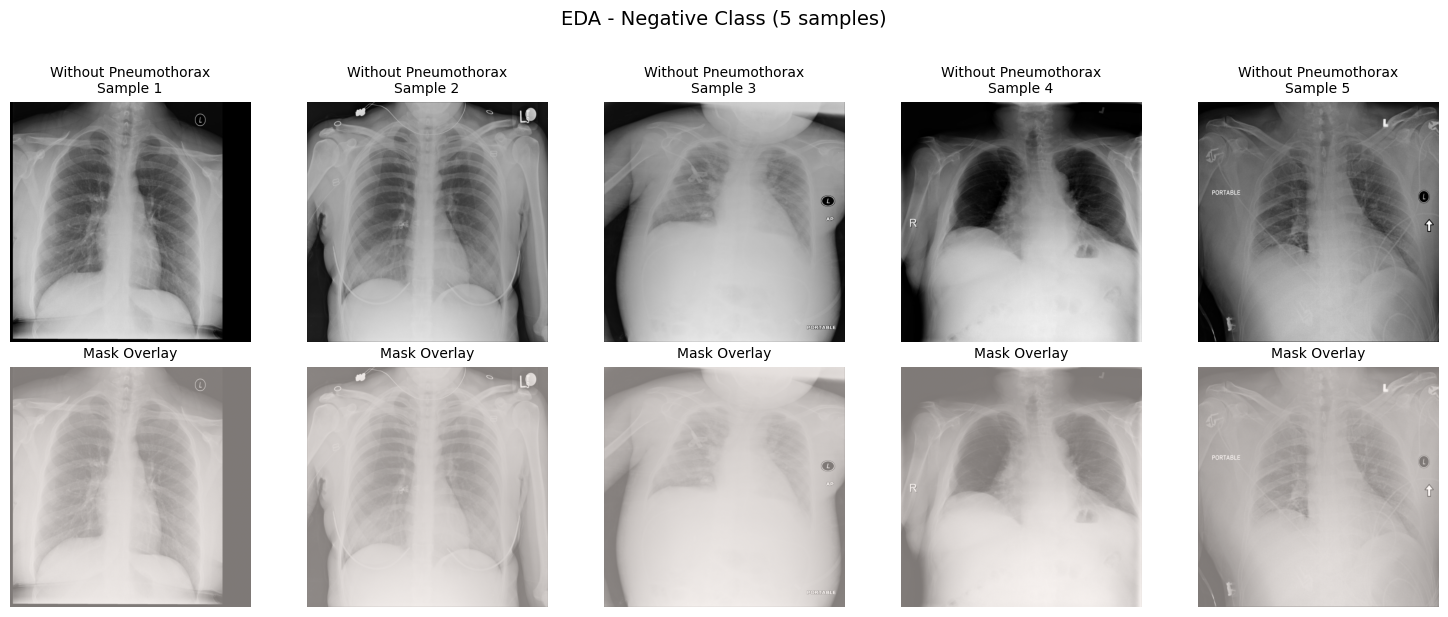

In [6]:
# EDA Visualization
GRAYSCALE_MEAN = np.array([0.5, 0.5, 0.5])
GRAYSCALE_STD = np.array([0.5, 0.5, 0.5])

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
if n_samples == 1:
    axes = axes.reshape(2, 1)

# Plot positive class
for i, idx in enumerate(pos_samples):
    image, mask = sample_dataset[i]
    
    img = image.permute(1, 2, 0).numpy()
    img = img * GRAYSCALE_STD + GRAYSCALE_MEAN
    img = np.clip(img, 0, 1)
    
    mask_np = mask.squeeze().numpy()
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'With Pneumothorax\nSample {i+1}', fontsize=10)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].imshow(mask_np, alpha=0.5, cmap='Reds')
    axes[1, i].set_title(f'Mask Overlay', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle(f'EDA - Positive Class ({len(pos_samples)} samples)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Plot negative class
fig2, axes2 = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
if n_samples == 1:
    axes2 = axes2.reshape(2, 1)

for i, idx in enumerate(neg_samples):
    dataset_idx = len(pos_samples) + i
    image, mask = sample_dataset[dataset_idx]
    
    img = image.permute(1, 2, 0).numpy()
    img = img * GRAYSCALE_STD + GRAYSCALE_MEAN
    img = np.clip(img, 0, 1)
    
    mask_np = mask.squeeze().numpy()
    
    axes2[0, i].imshow(img, cmap='gray')
    axes2[0, i].set_title(f'Without Pneumothorax\nSample {i+1}', fontsize=10)
    axes2[0, i].axis('off')
    
    axes2[1, i].imshow(img, cmap='gray')
    axes2[1, i].imshow(mask_np, alpha=0.5, cmap='Reds')
    axes2[1, i].set_title(f'Mask Overlay', fontsize=10)
    axes2[1, i].axis('off')

plt.suptitle(f'EDA - Negative Class ({len(neg_samples)} samples)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Load Best Model


In [7]:
# Load model
checkpoint = torch.load(config.MODEL_PATH, map_location=config.DEVICE)
encoder = checkpoint.get('encoder', config.ENCODER)
patch_size = checkpoint.get('patch_size', config.PATCH_SIZE)

model = smp.UnetPlusPlus(
    encoder_name=encoder,
    encoder_weights=config.ENCODER_WEIGHTS,
    in_channels=3,
    classes=1,
    activation=None,
    decoder_attention_type=config.ATTENTION_TYPE,
    decoder_dropout=0.0
)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(config.DEVICE)
model.eval()

print(f"Loaded model: {os.path.basename(config.MODEL_PATH)}")
print(f"Encoder: {encoder}")
print(f"Patch Size: {patch_size}")
print(f"Val Dice: {checkpoint.get('val_dice', 'N/A'):.4f}" if 'val_dice' in checkpoint else "Val Dice: N/A")
print(f"Val IoU: {checkpoint.get('val_iou', 'N/A'):.4f}" if 'val_iou' in checkpoint else "Val IoU: N/A")


Loaded model: pneumo_dice0.8411_iou0.8203_ep16.pth
Encoder: efficientnet-b1
Patch Size: 512
Val Dice: 0.8411
Val IoU: 0.8203


## TTA (Test-Time Augmentation) Functions


In [8]:
# TTA functions (same as training notebook)
def pad_to_divisible_by_32(x):
    _, _, H, W = x.shape
    output_stride = 32
    pad_h = (output_stride - H % output_stride) % output_stride
    pad_w = (output_stride - W % output_stride) % output_stride
    
    if pad_h == 0 and pad_w == 0:
        return x, (0, 0, 0, 0)
    
    padding = (pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2)
    x_padded = F.pad(x, padding, mode='reflect')
    return x_padded, padding

def crop_from_padding(x, padding):
    if padding == (0, 0, 0, 0):
        return x
    pad_left, pad_right, pad_top, pad_bottom = padding
    _, _, H, W = x.shape
    x_cropped = x[:, :, pad_top:H-pad_bottom, pad_left:W-pad_right]
    return x_cropped

def predict_with_tta(model, image, device, scales=(0.9, 1.0, 1.1), threshold=0.25):
    """Multi-scale + horizontal flip TTA."""
    model.eval()
    image = image.unsqueeze(0).to(device)
    _, _, H_orig, W_orig = image.shape

    logits_list = []

    with torch.no_grad():
        for s in scales:
            if s != 1.0:
                img_scaled = F.interpolate(
                    image, scale_factor=s, mode="bilinear", align_corners=False
                )
            else:
                img_scaled = image

            img_padded, padding = pad_to_divisible_by_32(img_scaled)
            _, _, H_pad, W_pad = img_padded.shape

            # Original
            logits = model(img_padded)
            logits = crop_from_padding(logits, padding)

            # Horizontal flip
            img_hflip = torch.flip(img_padded, dims=[3])
            logits_hflip = model(img_hflip)
            logits_hflip = torch.flip(logits_hflip, dims=[3])
            logits_hflip = crop_from_padding(logits_hflip, padding)

            # Average flip logits
            logits_avg = (logits + logits_hflip) / 2.0

            # Resize back to original size if needed
            if logits_avg.shape[-2:] != (H_orig, W_orig):
                logits_avg = F.interpolate(
                    logits_avg, size=(H_orig, W_orig), mode="bilinear", align_corners=False
                )

            logits_list.append(logits_avg)

        # Average across scales
        final_logits = torch.mean(torch.stack(logits_list), dim=0)

        prob = torch.sigmoid(final_logits)
        pred_binary = (prob > threshold).float()

    return (
        prob.squeeze().cpu().numpy(),
        pred_binary.squeeze().cpu().numpy()
    )

print("TTA functions defined")


TTA functions defined


In [9]:
# Evaluation metrics (same as training notebook)
def dice_per_sample(pred, target, eps=1e-6):
    pred_sum = pred.sum(dim=(1, 2, 3))
    target_sum = target.sum(dim=(1, 2, 3))
    intersection = (pred * target).sum(dim=(1, 2, 3))

    dice = torch.zeros_like(pred_sum)
    gt_empty = target_sum == 0
    dice[gt_empty] = (pred_sum[gt_empty] == 0).float()
    gt_nonempty = ~gt_empty
    dice[gt_nonempty] = (
        2 * intersection[gt_nonempty] + eps
    ) / (
        pred_sum[gt_nonempty] + target_sum[gt_nonempty] + eps
    )
    return dice

def evaluate_samples(model, dataset, device, threshold=0.25):
    """Evaluate samples with TTA."""
    model.eval()
    dice_scores = []
    iou_scores = []
    
    for idx in tqdm(range(len(dataset)), desc="Evaluating"):
        image, mask = dataset[idx]
        mask = mask.to(device)
        
        # Use TTA
        pred_prob, pred_binary = predict_with_tta(model, image, device, threshold=threshold)
        
        # Convert to tensors for metric calculation
        # pred_binary is (H, W) numpy array, need (B, C, H, W) tensor
        pred_tensor = torch.from_numpy(pred_binary).float().unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, H, W)
        
        # mask is (C, H, W) from dataset, need (B, C, H, W)
        mask_tensor = mask.unsqueeze(0)  # (1, C, H, W)
        
        # Ensure both have same shape
        if pred_tensor.shape != mask_tensor.shape:
            # If mask has different number of channels, squeeze/unsqueeze as needed
            if mask_tensor.shape[1] == 1:
                # Already correct
                pass
            else:
                mask_tensor = mask_tensor[:, :1, :, :]  # Take first channel if multiple
        
        # Calculate Dice
        dice = dice_per_sample(pred_tensor, mask_tensor)
        dice_scores.append(dice.item())
        
        # Calculate IoU
        intersection = (pred_tensor * mask_tensor).sum(dim=(1, 2, 3))
        union = pred_tensor.sum(dim=(1, 2, 3)) + mask_tensor.sum(dim=(1, 2, 3)) - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)
        iou_scores.append(iou.item())
    
    return {
        'dice_mean': np.mean(dice_scores),
        'dice_std': np.std(dice_scores),
        'iou_mean': np.mean(iou_scores),
        'iou_std': np.std(iou_scores),
        'dice_scores': dice_scores,
        'iou_scores': iou_scores
    }

print("Evaluation functions defined")


Evaluation functions defined


## Evaluate 10 test samples
Result will be different as we are picking either a higher or lower scoring sample


In [10]:
# Evaluate samples
threshold = 0.6  # Optimal threshold from training
results = evaluate_samples(model, sample_dataset, config.DEVICE, threshold=threshold)

print(f"\n{'='*60}")
print("EVALUATION RESULTS")
print(f"{'='*60}")
print(f"Dice Score: {results['dice_mean']:.4f} ± {results['dice_std']:.4f}")
print(f"IoU Score:  {results['iou_mean']:.4f} ± {results['iou_std']:.4f}")
print(f"{'='*60}\n")


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]


EVALUATION RESULTS
Dice Score: 0.6699 ± 0.4433
IoU Score:  0.6489 ± 0.4381



## Visualize Predictions


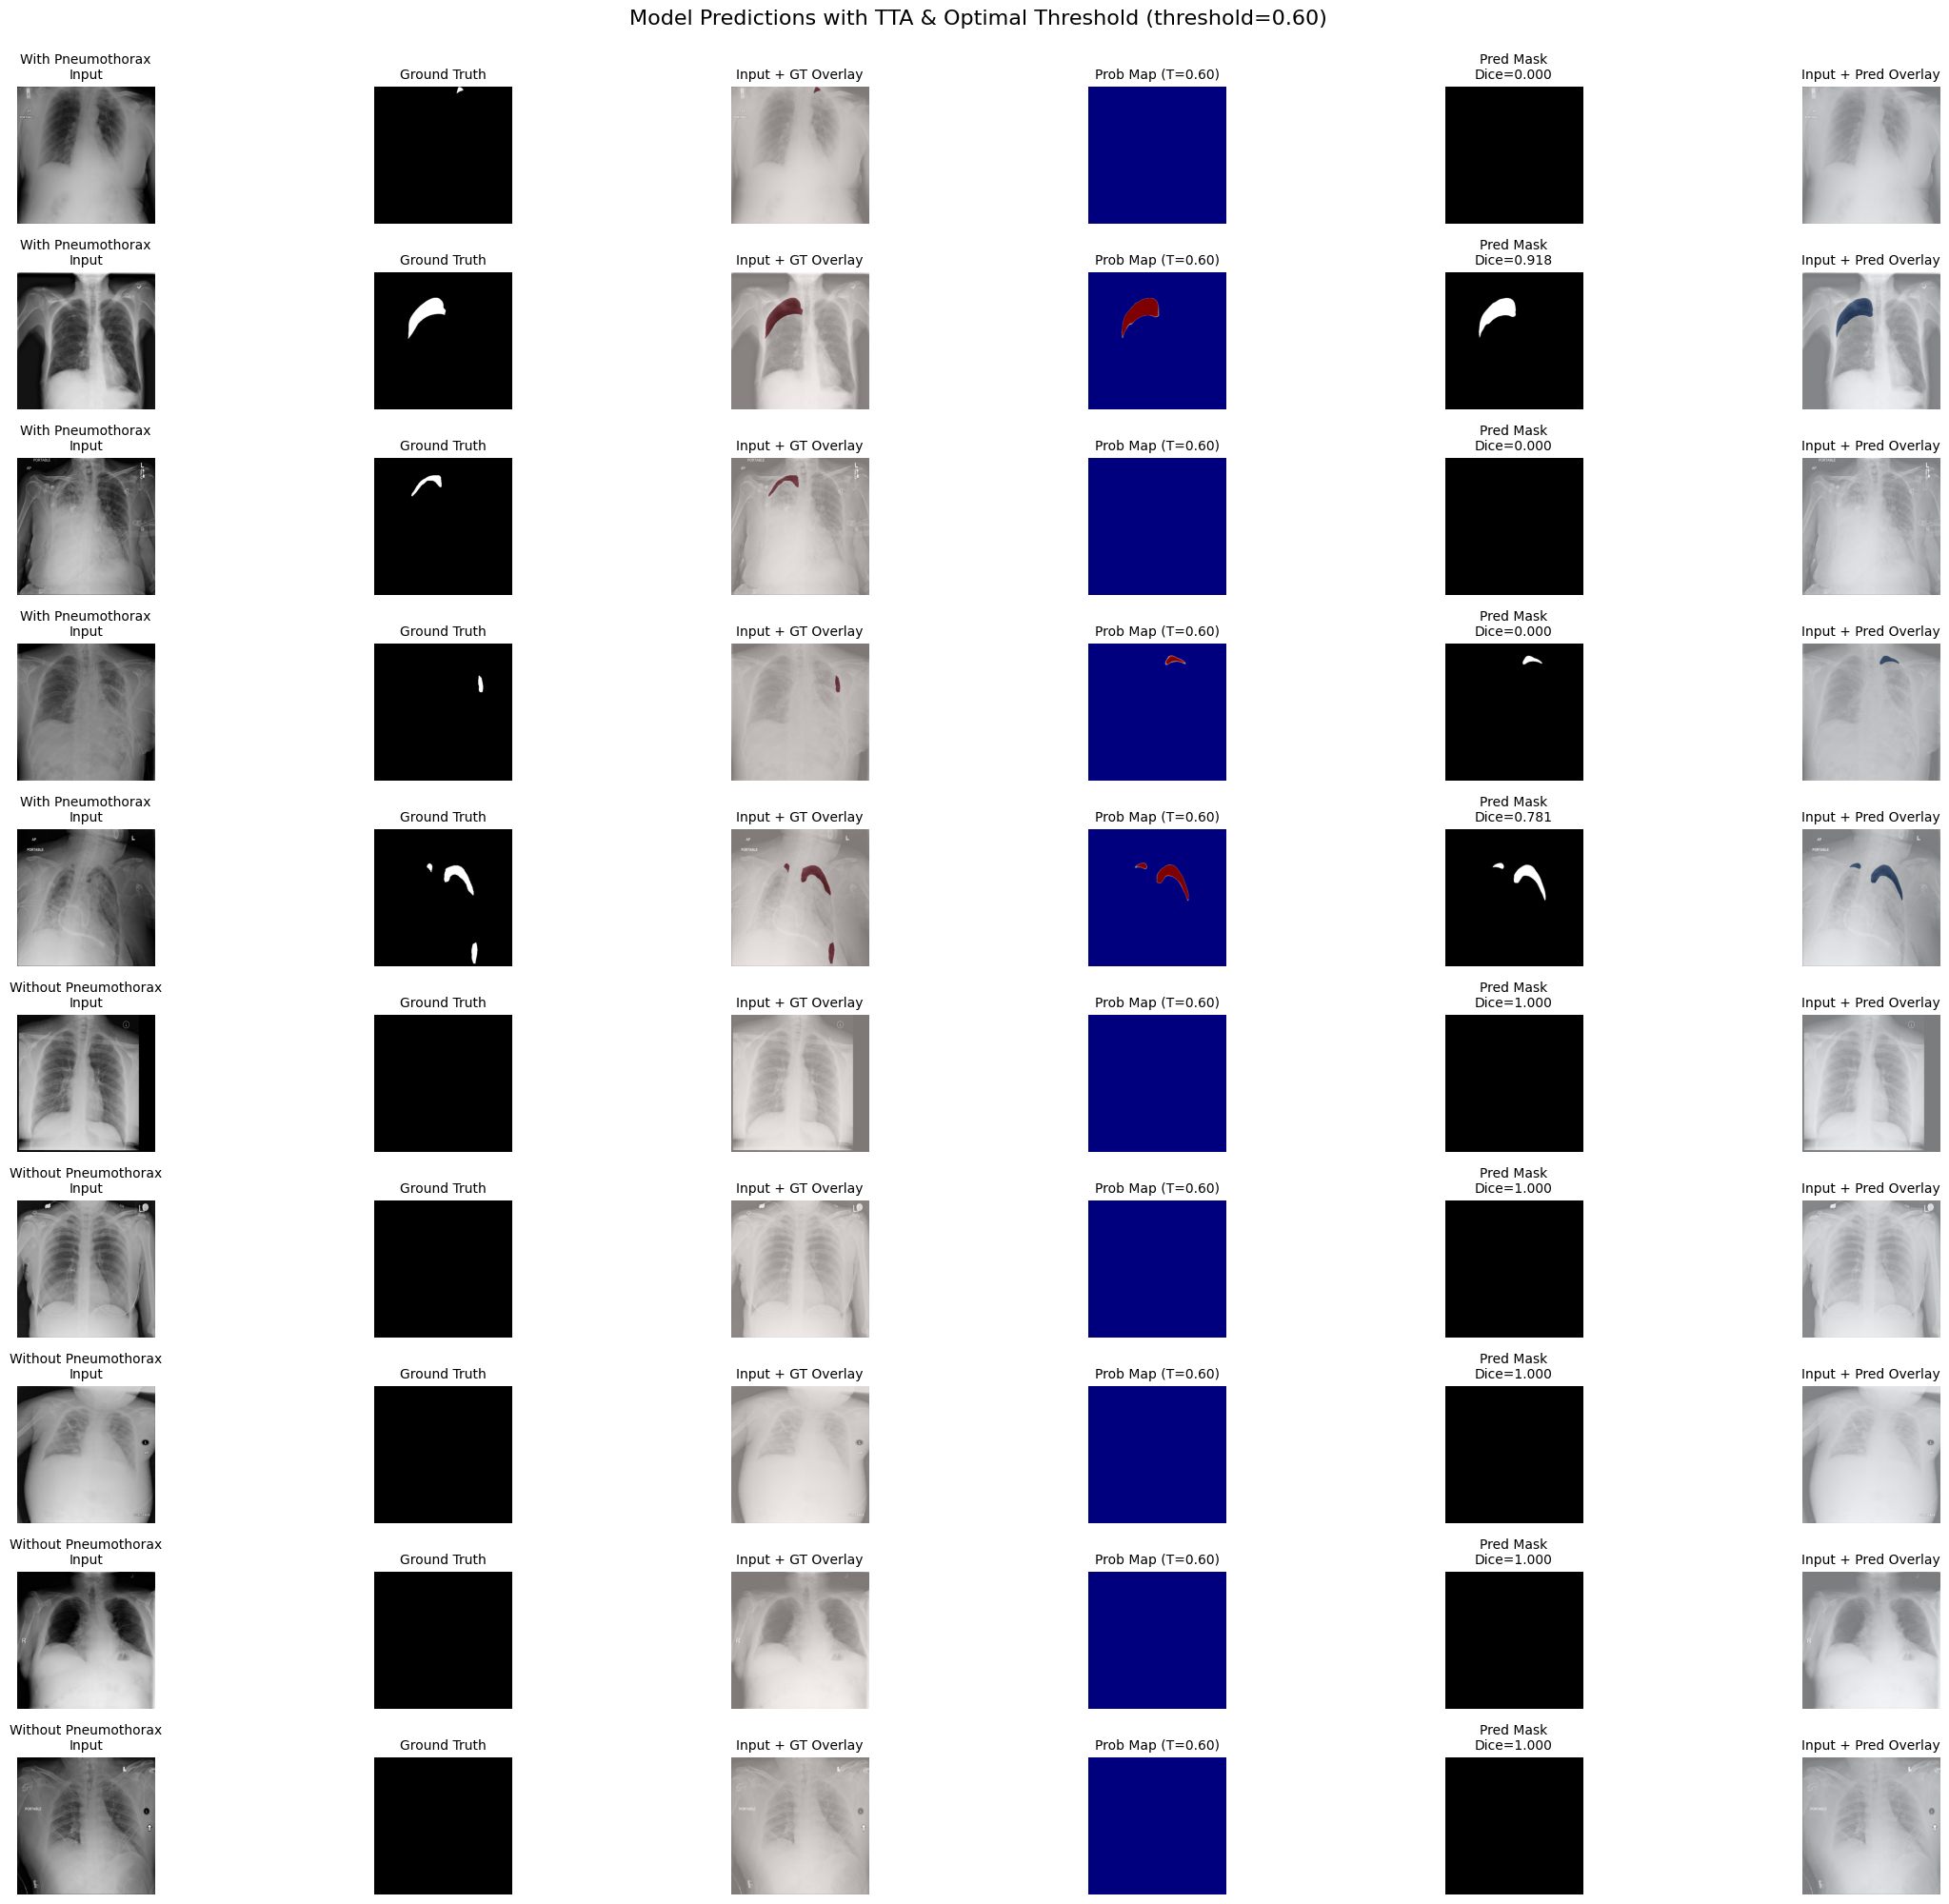

In [11]:
# Visualize predictions
n_total = len(sample_indices)
fig, axes = plt.subplots(n_total, 6, figsize=(24, n_total * 2))
if n_total == 1:
    axes = axes.reshape(1, 6)

for row, (idx, label) in enumerate(zip(range(len(sample_indices)), sample_labels)):
    image, mask = sample_dataset[idx]
    
    # Use TTA for prediction
    pred_prob, pred_binary = predict_with_tta(model, image, config.DEVICE, threshold=threshold)
    
    img = image.permute(1, 2, 0).numpy()
    img = img * GRAYSCALE_STD + GRAYSCALE_MEAN
    img = np.clip(img, 0, 1)
    mask_np = mask.squeeze().numpy()
    
    # Calculate sample Dice (with proper handling of empty masks)
    pred_sum = float(pred_binary.sum())
    mask_sum = float(mask_np.sum())
    
    # If both are empty, Dice = 1.0 (perfect match)
    if mask_sum == 0.0 and pred_sum == 0.0:
        sample_dice = 1.0
    elif mask_sum == 0.0 or pred_sum == 0.0:
        # If one is empty and the other isn't, Dice = 0.0
        sample_dice = 0.0
    else:
        # Standard Dice calculation
        intersection = float((pred_binary * mask_np).sum())
        sample_dice = 2.0 * intersection / (pred_sum + mask_sum + 1e-6)
    
    # Column 1: Input
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{label}\nInput', fontsize=10)
    axes[row, 0].axis('off')
    
    # Column 2: Ground Truth mask
    axes[row, 1].imshow(mask_np, cmap='gray')
    axes[row, 1].set_title('Ground Truth', fontsize=10)
    axes[row, 1].axis('off')
    
    # Column 3: Input + Ground Truth overlay
    axes[row, 2].imshow(img, cmap='gray')
    axes[row, 2].imshow(mask_np, alpha=0.5, cmap='Reds')
    axes[row, 2].set_title('Input + GT Overlay', fontsize=10)
    axes[row, 2].axis('off')
    
    # Column 4: Probability map
    axes[row, 3].imshow(pred_prob, cmap='jet', vmin=0, vmax=1)
    axes[row, 3].set_title(f'Prob Map (T={threshold:.2f})', fontsize=10)
    axes[row, 3].axis('off')
    
    # Column 5: Predicted mask
    axes[row, 4].imshow(pred_binary, cmap='gray')
    axes[row, 4].set_title(f'Pred Mask\nDice={sample_dice:.3f}', fontsize=10)
    axes[row, 4].axis('off')
    
    # Column 6: Input + Predicted mask overlay
    axes[row, 5].imshow(img, cmap='gray')
    axes[row, 5].imshow(pred_binary, alpha=0.5, cmap='Blues')
    axes[row, 5].set_title('Input + Pred Overlay', fontsize=10)
    axes[row, 5].axis('off')

plt.suptitle(f'Model Predictions with TTA & Optimal Threshold (threshold={threshold:.2f})', fontsize=16, y=0.998)
plt.tight_layout()
# plt.savefig('evaluation_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# print("Predictions saved to 'evaluation_predictions.png'")


# LGG Brain MRI

**Lightweight evaluation notebook for brain MRI segmentation model**

- Loads best model: `brain_mri_dice0.9121_iou0.8816_ep30.pth`
- Samples 5 images from each class (with/without lesion)
- Performs EDA visualization
- Evaluates with TTA (Test-Time Augmentation)
- Visualizes predictions

In [12]:
# Configuration for Brain MRI
class BrainMRIConfig:
    DATA_ROOT = "brain/flair/FLAIR/kaggle_3m"  # Root directory containing patient folders
    MODEL_PATH = "brain_mri_output/brain_mri_dice0.9121_iou0.8816_ep30.pth"
    
    ENCODER = "efficientnet-b3"
    ENCODER_WEIGHTS = "imagenet"
    ATTENTION_TYPE = "scse"
    IMAGE_SIZE = 256
    IN_CHANNELS = 1  # Grayscale, but converted to RGB
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 2
    NUM_WORKERS = 2
    
    SEED = 42

brain_config = BrainMRIConfig()

# Set seed
np.random.seed(brain_config.SEED)
torch.manual_seed(brain_config.SEED)
torch.cuda.manual_seed_all(brain_config.SEED)
torch.backends.cudnn.deterministic = True

print(f"Device: {brain_config.DEVICE}")
print(f"Model: {brain_config.MODEL_PATH}")


Device: cuda
Model: brain_mri_output/brain_mri_dice0.9121_iou0.8816_ep30.pth


In [13]:
# Dataset class for Brain MRI
class BrainMRIDataset(Dataset):
    """Dataset for FLAIR brain MRI with MAX POOLING for mask downsampling."""
    
    def __init__(self, image_mask_pairs, transform=None, image_size=256, in_channels=1):
        self.image_mask_pairs = image_mask_pairs
        self.transform = transform
        self.image_size = image_size
        self.in_channels = in_channels
    
    def __len__(self):
        return len(self.image_mask_pairs)
    
    def _max_pool_downsample_mask(self, mask, target_size):
        """Use max pooling to preserve small lesion regions during downsampling."""
        h, w = mask.shape
        if h == target_size and w == target_size:
            return mask
        
        ratio = h // target_size
        if ratio > 1 and h % target_size == 0 and w % target_size == 0:
            mask_reshaped = mask.reshape(target_size, ratio, target_size, ratio)
            mask_downsampled = mask_reshaped.max(axis=(1, 3))
            return mask_downsampled
        else:
            return cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    
    def __getitem__(self, idx):
        image_path, mask_path = self.image_mask_pairs[idx]
        
        # Load .tif files (FLAIR dataset uses TIF format)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if image is None:
            raise FileNotFoundError(f"Could not load image: {image_path}")
        if mask is None:
            mask = np.zeros_like(image)
        
        image = cv2.resize(image, (self.image_size, self.image_size))
        mask = self._max_pool_downsample_mask(mask, self.image_size)
        mask = (mask > 0).astype(np.float32)
        
        # Convert grayscale to RGB (3 channels)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        mask = np.expand_dims(mask, axis=-1)
        
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image, mask = transformed['image'], transformed['mask']
        
        if mask.dim() == 3:
            mask = mask.permute(2, 0, 1)
        else:
            mask = mask.unsqueeze(0)
        
        return image, mask

# Augmentation (validation - no random transforms)
def get_brain_validation_augmentation():
    return A.Compose([
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2()
    ])

print("Brain MRI Dataset class and augmentation defined")


Brain MRI Dataset class and augmentation defined


In [14]:
# Find all image-mask pairs in FLAIR dataset
def find_flair_image_mask_pairs(data_root):
    """Find all image-mask pairs in the FLAIR dataset."""
    image_mask_pairs = []
    
    if not os.path.exists(data_root):
        print(f"Data root not found: {data_root}")
        return image_mask_pairs
    
    # Get all patient folders
    patient_folders = [d for d in os.listdir(data_root) 
                       if os.path.isdir(os.path.join(data_root, d)) and d.startswith('TCGA_')]
    
    print(f"Found {len(patient_folders)} patient folders")
    
    for patient_folder in tqdm(patient_folders, desc="Scanning patient folders"):
        patient_path = os.path.join(data_root, patient_folder)
        
        # Get all .tif files in this patient folder
        all_tif_files = [f for f in os.listdir(patient_path) if f.lower().endswith('.tif')]
        
        # Separate images and masks
        image_files = [f for f in all_tif_files if not f.endswith('_mask.tif')]
        
        for img_file in image_files:
            base_name = img_file.replace('.tif', '')
            mask_file = f"{base_name}_mask.tif"
            
            image_path = os.path.join(patient_path, img_file)
            mask_path = os.path.join(patient_path, mask_file)
            
            if os.path.exists(image_path) and os.path.exists(mask_path):
                image_mask_pairs.append((image_path, mask_path))
    
    return image_mask_pairs

def validate_brain_sample(image_path, mask_path):
    """Validate a single image/mask pair and determine lesion label."""
    try:
        # Use torchvision.io for GPU-accelerated reading
        device = "cuda" if torch.cuda.is_available() else "cpu"
        mask = torchvision.io.read_image(mask_path).to(device)
        
        # Convert to grayscale if needed
        if mask.shape[0] > 1:
            mask = mask.mean(dim=0, keepdim=True)
        
        mask_max = mask.max().item() if mask is not None else 0
        has_lesion = 1 if mask_max > 0 else 0
        
        return (image_path, mask_path), has_lesion, None
    except Exception as e:
        return None, None, image_path

# Load TEST dataset
print(f"Scanning FLAIR dataset in: {brain_config.DATA_ROOT}")
all_pairs = find_flair_image_mask_pairs(brain_config.DATA_ROOT)

if len(all_pairs) == 0:
    # Try alternative path
    alt_path = "brain/flair/flair/kaggle_3m"
    print(f"Trying alternative path: {alt_path}")
    all_pairs = find_flair_image_mask_pairs(alt_path)
    if len(all_pairs) > 0:
        brain_config.DATA_ROOT = alt_path

print(f"\nFound {len(all_pairs)} image-mask pairs")

# Validate all pairs and determine labels
print("Determining lesion labels from TEST dataset (GPU-accelerated)...")
test_valid_pairs = []
test_has_lesion = []

with ThreadPoolExecutor(max_workers=16) as executor:
    futures = [executor.submit(validate_brain_sample, img_path, mask_path) 
               for img_path, mask_path in all_pairs]
    for f in tqdm(futures, desc="Checking masks"):
        try:
            pair, lesion, corrupt = f.result()
            if pair is not None:
                test_valid_pairs.append(pair)
                test_has_lesion.append(lesion)
        except Exception:
            continue

test_has_lesion = np.array(test_has_lesion)

print(f"\nTotal TEST samples: {len(test_valid_pairs)}")
print(f"With lesion: {test_has_lesion.sum()} ({100*test_has_lesion.mean():.1f}%)")
print(f"Without lesion: {len(test_has_lesion) - test_has_lesion.sum()} ({100*(1-test_has_lesion.mean()):.1f}%)")


Scanning FLAIR dataset in: brain/flair/FLAIR/kaggle_3m
Data root not found: brain/flair/FLAIR/kaggle_3m
Trying alternative path: brain/flair/flair/kaggle_3m
Data root not found: brain/flair/flair/kaggle_3m

Found 0 image-mask pairs
Determining lesion labels from TEST dataset (GPU-accelerated)...


Checking masks: 0it [00:00, ?it/s]


Total TEST samples: 0
With lesion: 0.0 (nan%)
Without lesion: 0.0 (nan%)


In [15]:
# Sample 5 images from each class
positive_indices = np.where(test_has_lesion == 1)[0]
negative_indices = np.where(test_has_lesion == 0)[0]

np.random.seed(brain_config.SEED)
n_samples = 5

pos_samples = np.random.choice(positive_indices, min(n_samples, len(positive_indices)), replace=False)
neg_samples = np.random.choice(negative_indices, min(n_samples, len(negative_indices)), replace=False)

sample_indices = np.concatenate([pos_samples, neg_samples])
sample_labels = ['With Lesion'] * len(pos_samples) + ['Without Lesion'] * len(neg_samples)

# Create dataset for samples
sample_pairs = [test_valid_pairs[i] for i in sample_indices]
sample_dataset = BrainMRIDataset(
    sample_pairs,
    get_brain_validation_augmentation(),
    brain_config.IMAGE_SIZE,
    brain_config.IN_CHANNELS
)

print(f"Selected {len(pos_samples)} samples with lesion")
print(f"Selected {len(neg_samples)} samples without lesion")


Selected 0 samples with lesion
Selected 0 samples without lesion


## EDA: Visualize Sample Images


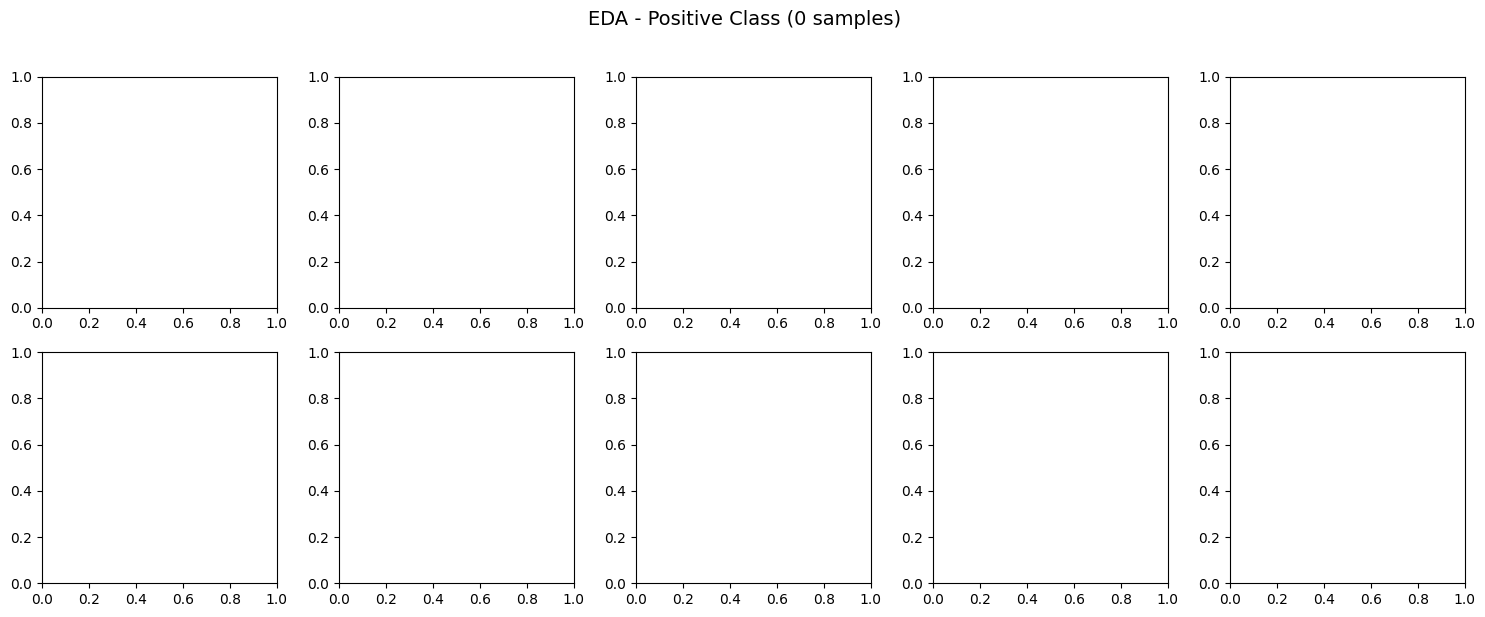

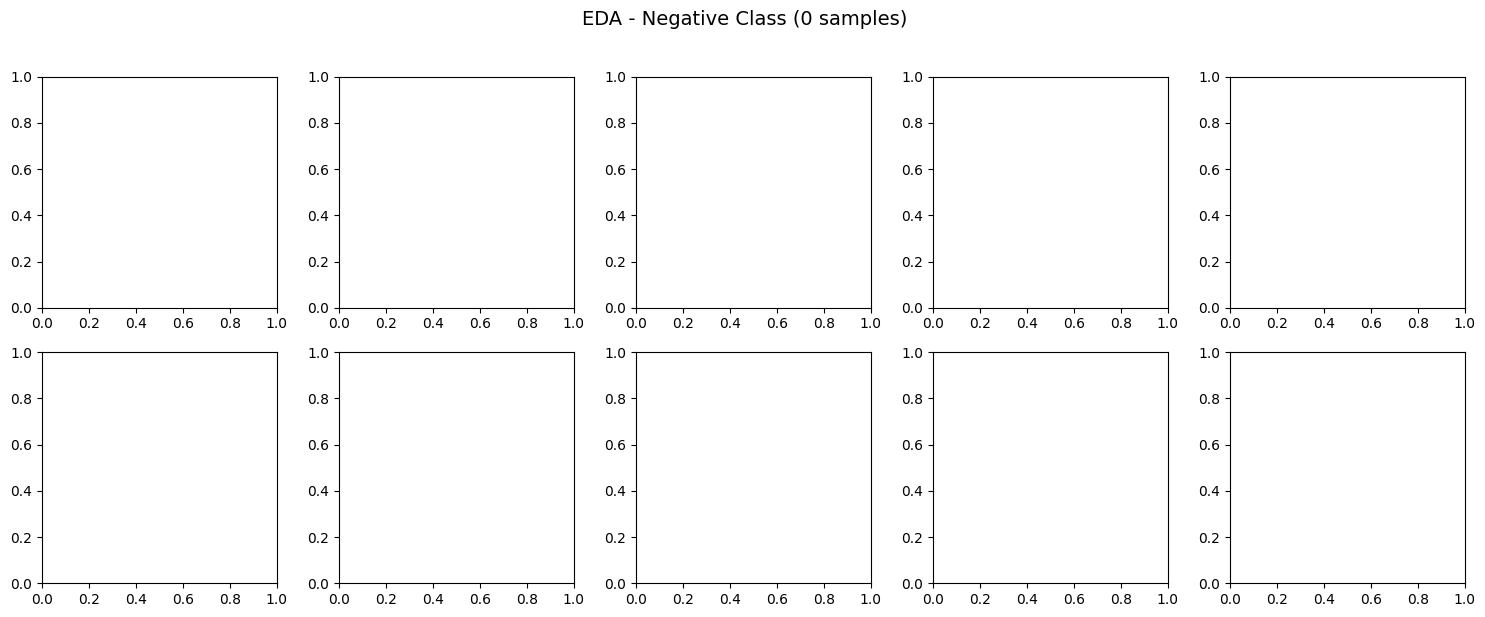

In [16]:
# EDA Visualization
GRAYSCALE_MEAN = np.array([0.5, 0.5, 0.5])
GRAYSCALE_STD = np.array([0.5, 0.5, 0.5])

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
if n_samples == 1:
    axes = axes.reshape(2, 1)

# Plot positive class
for i, idx in enumerate(pos_samples):
    dataset_idx = i
    image, mask = sample_dataset[dataset_idx]
    
    img = image.permute(1, 2, 0).numpy()
    img = img * GRAYSCALE_STD + GRAYSCALE_MEAN
    img = np.clip(img, 0, 1)
    # Take first channel for grayscale display
    img_gray = img[:, :, 0]
    
    mask_np = mask.squeeze().numpy()
    
    axes[0, i].imshow(img_gray, cmap='gray')
    axes[0, i].set_title(f'With Lesion\nSample {i+1}', fontsize=10)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(img_gray, cmap='gray')
    axes[1, i].imshow(mask_np, alpha=0.5, cmap='Reds')
    axes[1, i].set_title(f'Mask Overlay', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle(f'EDA - Positive Class ({len(pos_samples)} samples)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Plot negative class
fig2, axes2 = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
if n_samples == 1:
    axes2 = axes2.reshape(2, 1)

for i, idx in enumerate(neg_samples):
    dataset_idx = len(pos_samples) + i
    image, mask = sample_dataset[dataset_idx]
    
    img = image.permute(1, 2, 0).numpy()
    img = img * GRAYSCALE_STD + GRAYSCALE_MEAN
    img = np.clip(img, 0, 1)
    # Take first channel for grayscale display
    img_gray = img[:, :, 0]
    
    mask_np = mask.squeeze().numpy()
    
    axes2[0, i].imshow(img_gray, cmap='gray')
    axes2[0, i].set_title(f'Without Lesion\nSample {i+1}', fontsize=10)
    axes2[0, i].axis('off')
    
    axes2[1, i].imshow(img_gray, cmap='gray')
    axes2[1, i].imshow(mask_np, alpha=0.5, cmap='Reds')
    axes2[1, i].set_title(f'Mask Overlay', fontsize=10)
    axes2[1, i].axis('off')

plt.suptitle(f'EDA - Negative Class ({len(neg_samples)} samples)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Load Best Model


In [17]:
# Load model
checkpoint = torch.load(brain_config.MODEL_PATH, map_location=brain_config.DEVICE)
encoder = checkpoint.get('encoder', brain_config.ENCODER)
image_size = checkpoint.get('image_size', brain_config.IMAGE_SIZE)

model = smp.UnetPlusPlus(
    encoder_name=encoder,
    encoder_weights=brain_config.ENCODER_WEIGHTS,
    in_channels=3,  # RGB
    classes=1,
    activation=None,
    decoder_attention_type=brain_config.ATTENTION_TYPE,
    decoder_dropout=0.0
)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(brain_config.DEVICE)
model.eval()

print(f"Loaded model: {os.path.basename(brain_config.MODEL_PATH)}")
print(f"Encoder: {encoder}")
print(f"Image Size: {image_size}")
print(f"Val Dice: {checkpoint.get('val_dice', 'N/A'):.4f}" if 'val_dice' in checkpoint else "Val Dice: N/A")
print(f"Val IoU: {checkpoint.get('val_iou', 'N/A'):.4f}" if 'val_iou' in checkpoint else "Val IoU: N/A")


FileNotFoundError: [Errno 2] No such file or directory: 'brain_mri_output/brain_mri_dice0.9121_iou0.8816_ep30.pth'

## TTA (Test-Time Augmentation) Functions

*Note: TTA functions are already defined above (reused from pneumothorax section)*


## Evaluate 10 test samples
Result will be different as we are picking either a higher or lower scoring sample


In [ ]:
# Evaluate samples
threshold = 0.5  # Standard threshold for brain MRI
results = evaluate_samples(model, sample_dataset, brain_config.DEVICE, threshold=threshold)

print(f"\n{'='*60}")
print("EVALUATION RESULTS")
print(f"{'='*60}")
print(f"Dice Score: {results['dice_mean']:.4f} ± {results['dice_std']:.4f}")
print(f"IoU Score:  {results['iou_mean']:.4f} ± {results['iou_std']:.4f}")
print(f"{'='*60}\n")


## Visualize Predictions


In [ ]:
# Visualize predictions
n_total = len(sample_indices)
fig, axes = plt.subplots(n_total, 6, figsize=(24, n_total * 2))
if n_total == 1:
    axes = axes.reshape(1, 6)

for row, (idx, label) in enumerate(zip(range(len(sample_indices)), sample_labels)):
    image, mask = sample_dataset[idx]
    
    # Use TTA for prediction
    pred_prob, pred_binary = predict_with_tta(model, image, brain_config.DEVICE, threshold=threshold)
    
    img = image.permute(1, 2, 0).numpy()
    img = img * GRAYSCALE_STD + GRAYSCALE_MEAN
    img = np.clip(img, 0, 1)
    # Take first channel for grayscale display
    img_gray = img[:, :, 0]
    
    mask_np = mask.squeeze().numpy()
    
    # Calculate sample Dice (with proper handling of empty masks)
    pred_sum = float(pred_binary.sum())
    mask_sum = float(mask_np.sum())
    
    # If both are empty, Dice = 1.0 (perfect match)
    if mask_sum == 0.0 and pred_sum == 0.0:
        sample_dice = 1.0
    elif mask_sum == 0.0 or pred_sum == 0.0:
        # If one is empty and the other isn't, Dice = 0.0
        sample_dice = 0.0
    else:
        # Standard Dice calculation
        intersection = float((pred_binary * mask_np).sum())
        sample_dice = 2.0 * intersection / (pred_sum + mask_sum + 1e-6)
    
    # Column 1: Input
    axes[row, 0].imshow(img_gray, cmap='gray')
    axes[row, 0].set_title(f'{label}\nInput', fontsize=10)
    axes[row, 0].axis('off')
    
    # Column 2: Ground Truth mask
    axes[row, 1].imshow(mask_np, cmap='gray')
    axes[row, 1].set_title('Ground Truth', fontsize=10)
    axes[row, 1].axis('off')
    
    # Column 3: Input + Ground Truth overlay
    axes[row, 2].imshow(img_gray, cmap='gray')
    axes[row, 2].imshow(mask_np, alpha=0.5, cmap='Reds')
    axes[row, 2].set_title('Input + GT Overlay', fontsize=10)
    axes[row, 2].axis('off')
    
    # Column 4: Probability map
    axes[row, 3].imshow(pred_prob, cmap='jet', vmin=0, vmax=1)
    axes[row, 3].set_title(f'Prob Map (T={threshold:.2f})', fontsize=10)
    axes[row, 3].axis('off')
    
    # Column 5: Predicted mask
    axes[row, 4].imshow(pred_binary, cmap='gray')
    axes[row, 4].set_title(f'Pred Mask\nDice={sample_dice:.3f}', fontsize=10)
    axes[row, 4].axis('off')
    
    # Column 6: Input + Predicted mask overlay
    axes[row, 5].imshow(img_gray, cmap='gray')
    axes[row, 5].imshow(pred_binary, alpha=0.5, cmap='Blues')
    axes[row, 5].set_title('Input + Pred Overlay', fontsize=10)
    axes[row, 5].axis('off')

plt.suptitle(f'Brain MRI Model Predictions with TTA & Optimal Threshold (threshold={threshold:.2f})', fontsize=16, y=0.998)
plt.tight_layout()
# plt.savefig('brain_mri_evaluation_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# print("Predictions saved to 'brain_mri_evaluation_predictions.png'")
